In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
#Data 
test_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv')
test_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv')

train_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')
train_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')

included_cols = list(train_transaction.columns)
print('List columns: ' + str(included_cols) )
 
print('Test transactions shape: ' + str(test_transaction.shape) + ', identity ' + str(test_identity.shape) )
print('Train transactions shape: ' + str(train_transaction.shape) + ', identity ' + str(train_identity.shape) )
print('Train transactions preview:')
train_transaction.head(5)


List columns: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


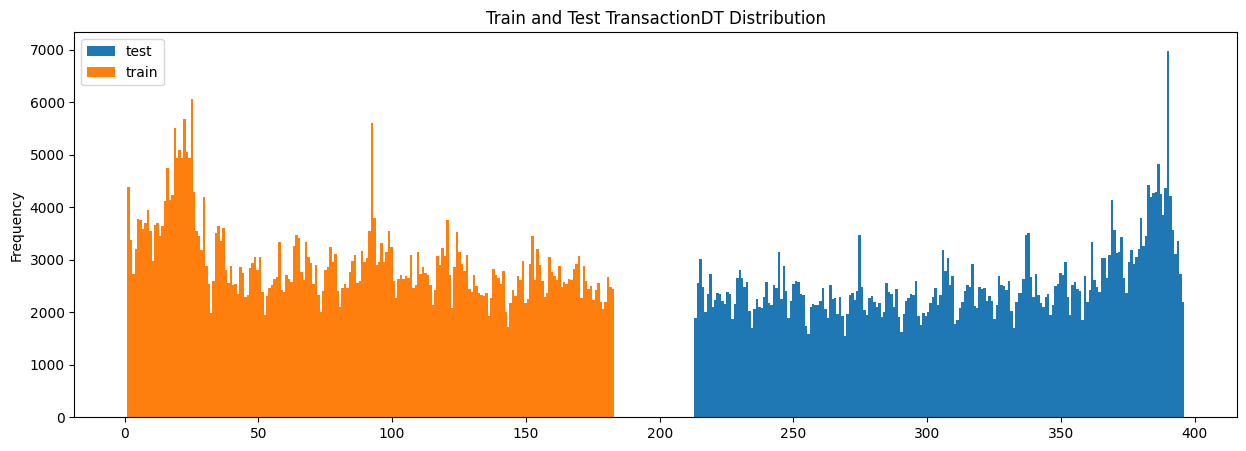

DayGroup,50,100,150,200,250,300,350,400,450+
Train,192688,157976,145240,94636,0,0,0,0,0
Test,0,0,0,0,95322,119132,130927,161310,0


In [3]:

train_transaction['TransactionDay'] = train_transaction['TransactionDT'] / 86400
test_transaction['TransactionDay'] = test_transaction['TransactionDT'] / 86400

test_transaction['TransactionDay'].plot(kind='hist', figsize=(15,5), label='test', 
                         bins=200, title='Train and Test TransactionDT Distribution')
train_transaction['TransactionDay'].plot(kind='hist',label='train',bins=200)
plt.legend()
plt.show()

bins = [0,50,100,150,200,250,300,350,400,float('inf')]
labels = ['50','100','150','200','250','300','350','400','450+']

train_transaction['DayGroup'] = pd.cut(
    train_transaction['TransactionDay'],
    bins=bins,
    labels=labels,
    right=False
)

test_transaction['DayGroup'] = pd.cut(
    test_transaction['TransactionDay'],
    bins=bins,
    labels=labels,
    right=False
)
train_count = train_transaction['DayGroup'].value_counts().sort_index()

test_count = test_transaction['DayGroup'].value_counts().sort_index()

summary = pd.DataFrame({
    'Train': train_count,
    'Test': test_count
})

summary.T

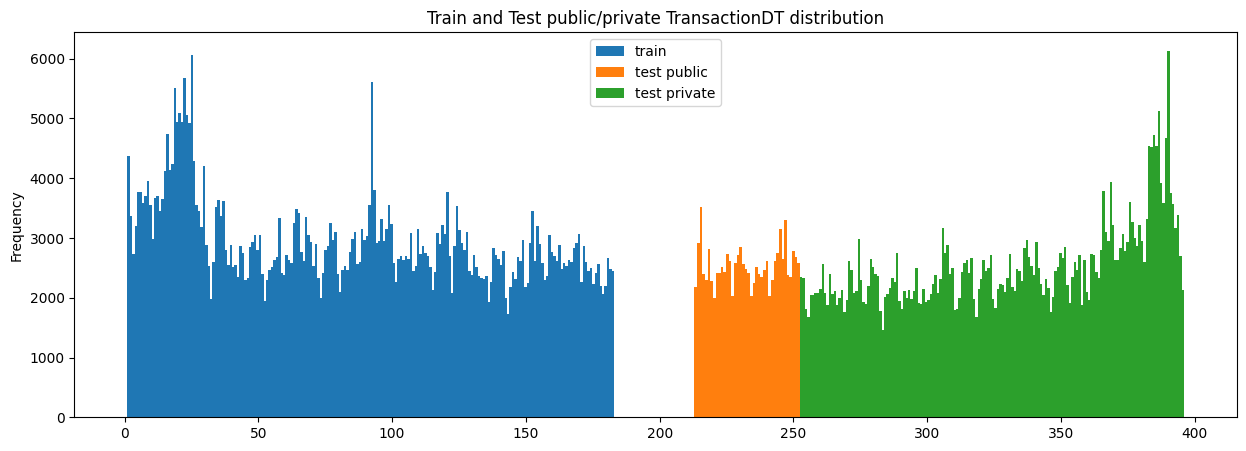

In [4]:
train_transaction['TransactionDay'].plot(kind='hist', figsize=(15, 5), label='train', 
                         bins=200, title='Train and Test public/private TransactionDT distribution')
n_public = int(test_transaction.shape[0] * 0.2) #20% of the test data is public
test_transaction.loc[:n_public, 'TransactionDay'].plot(kind='hist', label='test public', bins=40)
test_transaction.loc[n_public:, 'TransactionDay'].plot(kind='hist', label='test private', bins=160)
plt.legend()
plt.show()